<a href="https://colab.research.google.com/github/Shizukem/cu-i-k-/blob/main/b%C3%A0i_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gym
from gym import spaces
import numpy as np

# Define economic constants (placeholders - actual values should be set based on the problem description)
K0 = 1000.0  # Initial Capital
L0 = 100.0   # Initial Labor
D0_INIT = 20.0 # Initial Digital Capital
AI0 = 80.0   # Initial AI Capital
H0 = 50.0    # Initial Human Capital
A0 = 1.0     # Initial Total Factor Productivity
GDP_G0 = 5.0 # Initial GDP Growth Rate
UNEMP0 = 25.0 # Initial Unemployment Rate

ALPHA = 0.3  # Cobb-Douglas parameter for Capital
BETA_CD = 0.4 # Cobb-Douglas parameter for Labor
GAMMA_CD = 0.1 # Cobb-Douglas parameter for Digital Capital
DELTA = 0.1  # Cobb-Douglas parameter for AI Capital
THETA = 0.1  # Cobb-Douglas parameter for Human Capital

ALLOC = [
    [0.25, 0.25, 0.25, 0.25], # Action 0: Balanced
    [0.4, 0.2, 0.2, 0.2],    # Action 1: Invest more in K
    [0.2, 0.4, 0.2, 0.2],    # Action 2: Invest more in D
    [0.2, 0.2, 0.4, 0.2],    # Action 3: Invest more in AI
    [0.2, 0.2, 0.2, 0.4]     # Action 4: Invest more in H
] # Allocation strategies for BUDGET
BUDGET = 100.0 # Total budget for investment

W_REW = [0.5, 0.2, 0.15, 0.15] # Weights for reward components (GDP, Unemp, CyberRisk, Emission)

DK = 0.05    # Depreciation rate for Capital
DD = 0.1     # Depreciation rate for Digital Capital
DAI = 0.15   # Depreciation rate for AI Capital
THETA_H = 0.1 # Parameter for Human Capital growth
MU = 0.02    # Decay rate for Human Capital

PHI1 = 0.001 # TFP growth parameter related to Digital Capital
PHI2 = 0.001 # TFP growth parameter related to AI Capital
PHI3 = 0.001 # TFP growth parameter related to Human Capital
MAX_A_GROWTH = 1.05 # Maximum TFP growth factor

class VietnamEconomyEnv(gym.Env):
    """
    Môi trường MDP mô phỏng nền kinh tế Việt Nam.

    Không gian trạng thái: MultiDiscrete([3,3,3,3]) = 81 trạng thái
    Không gian hành động : Discrete(5)
    Episode              : T = 10 năm (2026-2035)
    """
    metadata = {'render_modes': []}

    def __init__(self):
        super().__init__()
        self.action_space      = spaces.Discrete(5)
        self.observation_space = spaces.MultiDiscrete([3, 3, 3, 3])
        self.T = 10   # 10 năm / episode

    # ── Rời rạc hóa trạng thái liên tục → chỉ số [0,1,2] ─────────
    def _discretize(self):
        s0 = 0 if self.gdp_g < 4.0 else (1 if self.gdp_g < 7.0 else 2)
        s1 = 0 if self.D     < 15. else (1 if self.D     < 25. else 2)
        s2 = 0 if self.AI    < 70. else (1 if self.AI    < 100. else 2)
        s3 = 0 if self.unemp < 20. else (1 if self.unemp < 35. else 2)
        return np.array([s0, s1, s2, s3], dtype=int)

    # ── Hàm sản xuất Cobb-Douglas ─────────────────────────────────
    def _production(self):
        return (self.A
                * max(self.K, 1.)**ALPHA
                * self.L**BETA_CD
                * max(self.D,  0.1)**GAMMA_CD
                * max(self.AI, 0.1)**DELTA
                * max(self.H,  0.1)**THETA)

    # ── Reset về trạng thái đầu VN 2026 ───────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.K     = K0;    self.L    = L0
        self.D     = D0_INIT; self.AI = AI0
        self.H     = H0;    self.A    = A0
        self.gdp_g = GDP_G0; self.unemp = UNEMP0
        self.Y_prev = self._production()
        self.t = 0
        return self._discretize(), {}

    # ── Một bước mô phỏng ─────────────────────────────────────────
    def step(self, action):
        a   = ALLOC[int(action)]
        IK  = a[0] * BUDGET
        ID  = a[1] * BUDGET
        IAI = a[2] * BUDGET
        IH  = a[3] * BUDGET

        # Lao động tăng 0.6%/năm
        self.L *= 1.006

        # Sản lượng mới
        Y = self._production()

        # Tăng trưởng GDP
        self.gdp_g = (Y / max(self.Y_prev, 1e-6) - 1.) * 100.

        # --- Tính reward theo công thức đề bài ---
        # Thành phần (1): ΔGDP — chuẩn hóa về [0,1]
        delta_gdp = max(self.gdp_g, 0.) / 15.   # max ~15%

        # Thành phần (2): Δunemp — AI giảm việc làm, H tạo việc làm
        delta_unemp = 0.3 * a[2] - 0.5 * a[3]
        self.unemp  = max(5., self.unemp + delta_unemp)

        # Thành phần (3): CyberRisk — AI tăng rủi ro, H giảm
        cyber_risk = max(0., 0.4 * a[2] - 0.2 * a[3])

        # Thành phần (4): Emission — K và AI tiêu thụ điện nhiều
        emission = 0.5 * a[0] + 0.3 * a[2]

        reward = (W_REW[0] * delta_gdp
                - W_REW[1] * max(delta_unemp, 0.)
                - W_REW[2] * cyber_risk
                - W_REW[3] * emission)

        # --- Cập nhật trạng thái kinh tế ---
        self.K  = (1 - DK)  * self.K  + IK
        self.D  = (1 - DD)  * self.D  + ID
        self.AI = (1 - DAI) * self.AI + IAI
        self.H  = max(self.H + THETA_H * IH / 100. - MU * self.H, 0.1)
        A_growth = 1. + PHI1 * self.D + PHI2 * self.AI + PHI3 * self.H
        self.A  = self.A * min(A_growth, MAX_A_GROWTH)
        self.Y_prev = Y
        self.t += 1

        done = (self.t >= self.T)
        return self._discretize(), reward, done, False, {}

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
def train_qlearning(n_episodes=10_000, alpha=0.1, gamma_rl=0.95,
                    eps_start=1.0, eps_end=0.05):
    """
    Tabular Q-learning với ε-greedy.
    Q-table: shape (3,3,3,3,5) = 81 × 5 = 405 giá trị
    """
    env = VietnamEconomyEnv()
    Q   = np.zeros((3, 3, 3, 3, 5))
    ep_rewards = []

    for ep in range(n_episodes):
        # ε giảm tuyến tính từ eps_start → eps_end
        eps = eps_end + (eps_start - eps_end) * max(0., 1. - ep / (n_episodes * 0.8))

        s, _ = env.reset()
        ep_r  = 0.

        while True:
            # ε-greedy
            if np.random.rand() < eps:
                a = env.action_space.sample()
            else:
                a = int(np.argmax(Q[tuple(s)]))

            s2, r, done, _, _ = env.step(a)

            # Cập nhật Q
            Q[tuple(s) + (a,)] += alpha * (
                r + gamma_rl * np.max(Q[tuple(s2)]) - Q[tuple(s) + (a,)]
            )
            s   = s2
            ep_r += r
            if done:
                break

        ep_rewards.append(ep_r)

    return Q, ep_rewards, env

In [3]:
print('=' * 68)
print('  BÀI 11 — HỌC TĂNG CƯỜNG Q-LEARNING CHO CHÍNH SÁCH KINH TẾ')
print('  MDP: 81 trạng thái × 5 hành động  |  10.000 episodes')
print('=' * 68)

print('\n[ Câu 11.3.1 ] Môi trường gymnasium VietnamEconomyEnv')
print('-' * 60)
env_test = VietnamEconomyEnv()
obs0, _ = env_test.reset()
print(f'  Không gian trạng thái: {env_test.observation_space}  (= 81 trạng thái)')
print(f'  Không gian hành động : {env_test.action_space}    (= 5 chiến lược)')
print(f'  Thời gian / episode  : T = {env_test.T} năm')
print(f'  Trạng thái khởi đầu (VN 2026): s = {obs0}')
print(f'    → s0=GDP growth={obs0[0]} (high>7%)  s1=Digital={obs0[1]} (med)')
print(f'       s2=AI={obs0[2]} (med 70-100k)     s3=Unemp={obs0[3]} (med 20-35%)')

# Test 1 step
obs1, r1, d1, _, _ = env_test.step(1)
print(f'\n  Test bước đầu tiên (hành động a1 — Cân bằng):')
print(f'    Reward = {r1:.4f}  |  Trạng thái mới = {obs1}  |  Done = {d1}')

print('\n[ Câu 11.3.2 ] Q-learning: α=0.1, γ=0.95, ε: 1.0→0.05, 10.000 ep')
print('-' * 60)
print('  Đang huấn luyện...', end='', flush=True)

Q_table, rewards_hist, env_trained = train_qlearning(
    n_episodes=10_000, alpha=0.1, gamma_rl=0.95,
    eps_start=1.0, eps_end=0.05
)

print(f' Xong!')
print(f'  Q-table shape: {Q_table.shape}  ({Q_table.size} giá trị)')
print(f'  Reward TB 1.000 ep đầu : {np.mean(rewards_hist[:1000]):>8.4f}')
print(f'  Reward TB 1.000 ep cuối: {np.mean(rewards_hist[-1000:]):>8.4f}')
print(f'  Cải thiện: {np.mean(rewards_hist[-1000:])-np.mean(rewards_hist[:1000]):>+.4f}')

  BÀI 11 — HỌC TĂNG CƯỜNG Q-LEARNING CHO CHÍNH SÁCH KINH TẾ
  MDP: 81 trạng thái × 5 hành động  |  10.000 episodes

[ Câu 11.3.1 ] Môi trường gymnasium VietnamEconomyEnv
------------------------------------------------------------
  Không gian trạng thái: MultiDiscrete([3 3 3 3])  (= 81 trạng thái)
  Không gian hành động : Discrete(5)    (= 5 chiến lược)
  Thời gian / episode  : T = 10 năm
  Trạng thái khởi đầu (VN 2026): s = [1 1 1 1]
    → s0=GDP growth=1 (high>7%)  s1=Digital=1 (med)
       s2=AI=1 (med 70-100k)     s3=Unemp=1 (med 20-35%)

  Test bước đầu tiên (hành động a1 — Cân bằng):
    Reward = -0.0370  |  Trạng thái mới = [0 2 1 1]  |  Done = False

[ Câu 11.3.2 ] Q-learning: α=0.1, γ=0.95, ε: 1.0→0.05, 10.000 ep
------------------------------------------------------------
  Đang huấn luyện... Xong!
  Q-table shape: (3, 3, 3, 3, 5)  (405 giá trị)
  Reward TB 1.000 ep đầu :   1.8816
  Reward TB 1.000 ep cuối:   1.9649
  Cải thiện: +0.0833


In [4]:
print('''
[ Câu 11.3.3 ] Chính sách tối ưu π*(s) = argmax_a Q(s,a)''')
print('-' * 60)

# Define action names for better readability
ACT_NAMES = [
    "Cân bằng",
    "Đầu tư K",
    "Đầu tư D",
    "Đầu tư AI",
    "Đầu tư H"
]

# Chính sách tại trạng thái khởi đầu VN 2026 và 4 trạng thái giả định
test_states = {
    'VN 2026 (thực tế)':      np.array([2, 1, 1, 1]),   # gdp_high, dig_med, ai_med, u_med
    'GDP thấp, D thấp, U cao': np.array([0, 0, 0, 2]),  # crisis
    'GDP cao, AI cao, U thấp': np.array([2, 2, 2, 0]),  # boom
    'GDP trung, D cao, U med': np.array([1, 2, 1, 1]),  # digital maturity
    'GDP thấp, AI med, U med': np.array([0, 1, 1, 1]),  # stagnation
}

print(f'\n  {"Trạng thái":<32} {"State":>12}  {"π*(s)":>6}  {"Q-values":<40}  {"Diễn giải"}')
print('  ' + '-' * 108)

pi_star = {}
for name, s in test_states.items():
    q_vals = Q_table[tuple(s)]
    best_a = int(np.argmax(q_vals))
    pi_star[name] = best_a
    q_str  = '  '.join([f'{v:.3f}' for v in q_vals])
    print(f'  {name:<32} {str(s.tolist()):>12}  a{best_a:<5}  [{q_str}]  '
          f'→ {ACT_NAMES[best_a]}')

# ── Bản đồ chính sách đầy đủ (in tóm tắt) ───────────────────────
print(f'\n  Phân bố hành động tối ưu trên 81 trạng thái:')
pi_full = np.argmax(Q_table, axis=4)
for a in range(5):
    cnt = (pi_full == a).sum()
    print(f'    {ACT_NAMES[a]:<22}: {cnt:>3} trạng thái ({cnt/81*100:.0f}%)')


[ Câu 11.3.3 ] Chính sách tối ưu π*(s) = argmax_a Q(s,a)
------------------------------------------------------------

  Trạng thái                              State   π*(s)  Q-values                                  Diễn giải
  ------------------------------------------------------------------------------------------------------------
  VN 2026 (thực tế)                [2, 1, 1, 1]  a0      [0.000  0.000  0.000  0.000  0.000]  → Cân bằng
  GDP thấp, D thấp, U cao          [0, 0, 0, 2]  a0      [0.000  0.000  0.000  0.000  0.000]  → Cân bằng
  GDP cao, AI cao, U thấp          [2, 2, 2, 0]  a0      [0.000  0.000  0.000  0.000  0.000]  → Cân bằng
  GDP trung, D cao, U med          [1, 2, 1, 1]  a0      [0.000  0.000  0.000  0.000  0.000]  → Cân bằng
  GDP thấp, AI med, U med          [0, 1, 1, 1]  a0      [0.000  0.000  0.000  0.000  0.000]  → Cân bằng

  Phân bố hành động tối ưu trên 81 trạng thái:
    Cân bằng              :  75 trạng thái (93%)
    Đầu tư K              :   0 trạng 

In [5]:
print('\n[ Câu 11.3.4 ] So sánh π* vs. 3 chính sách rule-based')
print('-' * 60)

def run_policy(policy_fn, n_runs=200, seed_offset=0):
    """Chạy n_runs episodes với policy_fn, trả về rewards."""
    env_eval = VietnamEconomyEnv()
    ep_rewards = []
    for run in range(n_runs):
        s, _ = env_eval.reset(seed=run + seed_offset)
        ep_r  = 0.
        while True:
            a = policy_fn(s)
            s, r, done, _, _ = env_eval.step(a)
            ep_r += r
            if done:
                break
        ep_rewards.append(ep_r)
    return np.array(ep_rewards)

# Các chính sách
def policy_qstar(s):   return int(np.argmax(Q_table[tuple(s)]))
def policy_a1(s):      return 1    # luôn Cân bằng
def policy_a3(s):      return 3    # luôn AI dẫn dắt
def policy_random(s):  return np.random.randint(5)

policies = {
    'π* (Q-learning)': policy_qstar,
    'Luôn a1 (Cân bằng)':   policy_a1,
    'Luôn a3 (AI dẫn dắt)': policy_a3,
    'Random':                policy_random,
}

eval_results = {}
for name, pol in policies.items():
    rew = run_policy(pol, n_runs=300, seed_offset=9999)
    eval_results[name] = rew
    print(f'  {name:<28}: μ={rew.mean():>7.4f}  σ={rew.std():>6.4f}  '
          f'min={rew.min():>7.4f}  max={rew.max():>7.4f}')


[ Câu 11.3.4 ] So sánh π* vs. 3 chính sách rule-based
------------------------------------------------------------
  π* (Q-learning)             : μ= 2.0031  σ=0.0000  min= 2.0031  max= 2.0031
  Luôn a1 (Cân bằng)          : μ= 1.8060  σ=0.0000  min= 1.8060  max= 1.8060
  Luôn a3 (AI dẫn dắt)        : μ= 1.7430  σ=0.0000  min= 1.7430  max= 1.7430
  Random                      : μ= 1.8814  σ=0.0348  min= 1.8035  max= 1.9764


In [6]:
import random # Add this import statement

print(f"\n{'='*72}")
print(f"CÂU 11.3.5 (Mở rộng): Deep Q-Network (DQN) cài đặt bằng numpy")
print(f"  Neural network: Input(4) → Hidden(64) → Hidden(64) → Output(5)")
print(f"{'='*72}")

class SimpleNeuralNet:
    """
    Neural network 2 hidden layers cài đặt bằng numpy.
    Kiến trúc: 4 → 64 → 64 → 5 (ReLU activation, không có BatchNorm)
    """
    def __init__(self, input_dim=4, hidden_dim=64, output_dim=5, lr=1e-3):
        self.lr = lr
        # Khởi tạo trọng số He initialization
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros(hidden_dim)
        self.W3 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b3 = np.zeros(output_dim)

    def relu(self, x):       return np.maximum(0, x)
    def relu_deriv(self, x): return (x > 0).astype(float)

    def forward(self, x):
        """Forward pass, trả về Q-values và cache để backprop."""
        self.x0  = x
        self.z1  = x @ self.W1 + self.b1
        self.a1  = self.relu(self.z1)
        self.z2  = self.a1 @ self.W2 + self.b2
        self.a2  = self.relu(self.z2)
        self.out = self.a2 @ self.W3 + self.b3
        return self.out

    def backward(self, grad_out):
        """Backpropagation với gradient từ loss."""
        dW3 = self.a2.T @ grad_out
        db3 = grad_out.sum(axis=0)

        da2    = grad_out @ self.W3.T
        dz2    = da2 * self.relu_deriv(self.z2)
        dW2    = self.a1.T @ dz2
        db2    = dz2.sum(axis=0)

        da1    = dz2 @ self.W2.T
        dz1    = da1 * self.relu_deriv(self.z1)
        dW1    = self.x0.T @ dz1
        db1    = dz1.sum(axis=0)

        # Gradient descent
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1


class ReplayBuffer:
    """Experience Replay Buffer (DQN cốt lõi - Mnih et al., 2015)."""
    def __init__(self, capacity=5000):
        self.capacity = capacity
        self.buffer   = []
        self.pos      = 0

    def push(self, s, a, r, s_next, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.pos] = (s, a, r, s_next, done)
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self): return len(self.buffer)


def state_to_vec(s):
    """Chuyển trạng thái tuple (4,) thành vector one-hot (12,) → input NN."""
    # One-hot encoding: mỗi chiều có 3 levels → 4×3 = 12 features
    # Hoặc dùng normalized scalar (đơn giản hơn cho demo)
    return np.array(s, dtype=float) / 2.0  # normalize về [0,1]


def run_dqn(
    env,
    n_episodes  = 3_000,
    batch_size  = 64,
    gamma       = 0.95,
    lr           = 5e-4,
    eps_start   = 1.0,
    eps_end     = 0.05,
    eps_decay   = 2_000,
    target_update_freq = 50,   # cập nhật target network
    min_buffer  = 256,
    verbose     = True,
):
    """
    Deep Q-Network (DQN) đơn giản với Experience Replay và Target Network.
    Tham khảo: Mnih et al. (2015), Nature 518:529-533.
    """
    net        = SimpleNeuralNet(input_dim=4, hidden_dim=64, output_dim=5, lr=lr)
    target_net = SimpleNeuralNet(input_dim=4, hidden_dim=64, output_dim=5, lr=lr)
    # Khởi tạo target net = online net
    target_net.W1, target_net.b1 = net.W1.copy(), net.b1.copy()
    target_net.W2, target_net.b2 = net.W2.copy(), net.b2.copy()
    target_net.W3, target_net.b3 = net.W3.copy(), net.b3.copy()

    replay = ReplayBuffer(capacity=5000)
    rewards_dqn = []

    for ep in range(n_episodes):
        eps = max(eps_end, eps_start - (eps_start - eps_end) * ep / eps_decay)
        obs, _ = env.reset()
        total_r = 0.0
        done    = False

        while not done:
            # Epsilon-greedy với neural network
            if np.random.rand() < eps:
                a = np.random.randint(env.action_space.n)
            else:
                s_vec  = state_to_vec(obs).reshape(1, -1)
                q_vals = net.forward(s_vec)[0]
                a      = int(np.argmax(q_vals))

            obs_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            replay.push(obs, a, r, obs_next, done)
            obs = obs_next
            total_r += r

            # Training step
            if len(replay) >= min_buffer:
                batch = replay.sample(batch_size)
                s_b    = np.array([state_to_vec(b[0]) for b in batch])
                a_b    = np.array([b[1] for b in batch])
                r_b    = np.array([b[2] for b in batch])
                s_next_b = np.array([state_to_vec(b[3]) for b in batch])
                done_b = np.array([b[4] for b in batch], dtype=float)

                # Target Q values (sử dụng target network)
                q_next    = target_net.forward(s_next_b)
                y_target  = r_b + gamma * np.max(q_next, axis=1) * (1 - done_b)

                # Forward qua online network
                q_pred = net.forward(s_b)

                # Tính gradient của MSE loss chỉ tại action được chọn
                grad = np.zeros_like(q_pred)
                for i in range(batch_size):
                    grad[i, a_b[i]] = 2.0 * (q_pred[i, a_b[i]] - y_target[i]) / batch_size

                net.backward(grad)

        # Cập nhật target network định kỳ
        if (ep + 1) % target_update_freq == 0:
            target_net.W1, target_net.b1 = net.W1.copy(), net.b1.copy()
            target_net.W2, target_net.b2 = net.W2.copy(), net.b2.copy()
            target_net.W3, target_net.b3 = net.W3.copy(), net.b3.copy()

        rewards_dqn.append(total_r)

        if verbose and (ep + 1) % 1000 == 0:
            print(f"  DQN Ep {ep+1:>5}/{n_episodes} | ε={eps:.3f} | "
                  f"Reward TB (200 ep): {np.mean(rewards_dqn[-200:]):.4f}")

    return net, rewards_dqn

# Define run_policy, env_eval, and N_EVAL for DQN evaluation
def run_policy(policy_fn, n_runs=200, seed_offset=0):
    """Chạy n_runs episodes với policy_fn, trả về rewards."""
    env_eval_local = VietnamEconomyEnv() # Use a local env instance
    ep_rewards = []
    for run in range(n_runs):
        s, _ = env_eval_local.reset(seed=run + seed_offset)
        ep_r  = 0.
        while True:
            a = policy_fn(s)
            s, r, done, _, _ = env_eval_local.step(a)
            ep_r += r
            if done:
                break
        ep_rewards.append(ep_r)
    return np.array(ep_rewards)

env_eval = VietnamEconomyEnv() # Define env_eval
N_EVAL = 300 # Define N_EVAL, consistent with previous evaluation

print("\n  Huấn luyện DQN (3.000 episodes — demo so sánh kiến trúc)...")
env_dqn = VietnamEconomyEnv()
np.random.seed(42); random.seed(42)

dqn_net, rewards_dqn = run_dqn(
    env_dqn,
    n_episodes = 3_000,
    batch_size = 64,
    gamma      = 0.95,
    lr         = 5e-4,
    eps_start  = 1.0,
    eps_end    = 0.05,
    eps_decay  = 2_000,
    target_update_freq = 50,
    verbose    = True,
)

# Đánh giá DQN
def policy_dqn(obs):
    s_vec  = state_to_vec(obs).reshape(1, -1)
    q_vals = dqn_net.forward(s_vec)[0]
    return int(np.argmax(q_vals))

np.random.seed(999)
rews_dqn_eval = run_policy(policy_dqn, n_runs=N_EVAL, seed_offset=200)
eval_results['DQN (numpy)'] = rews_dqn_eval # Corrected variable name

print(f"\n  DQN vs Q-learning tabular:")
print(f"    Q-learning : {np.mean(eval_results['π* (Q-learning)']):.4f} ± {np.std(eval_results['π* (Q-learning)']):.4f}") # Corrected variable name
print(f"    DQN        : {np.mean(rews_dqn_eval):.4f} ± {np.std(rews_dqn_eval):.4f}")
dqn_diff = np.mean(rews_dqn_eval) - np.mean(eval_results['π* (Q-learning)']) # Corrected variable name
print(f"    Chênh lệch : {dqn_diff:+.4f} ({'DQN tốt hơn' if dqn_diff > 0 else 'Q-learning tabular tốt hơn'} cho bài toán này)")
print(f"  → Lý giải: Với 81 trạng thái (nhỏ), Q-table đủ dung lượng học tốt.")
print(f"    DQN có lợi khi không gian trạng thái lớn (liên tục / nhiều chiều).")


CÂU 11.3.5 (Mở rộng): Deep Q-Network (DQN) cài đặt bằng numpy
  Neural network: Input(4) → Hidden(64) → Hidden(64) → Output(5)

  Huấn luyện DQN (3.000 episodes — demo so sánh kiến trúc)...
  DQN Ep  1000/3000 | ε=0.525 | Reward TB (200 ep): 1.8772
  DQN Ep  2000/3000 | ε=0.050 | Reward TB (200 ep): 1.9117
  DQN Ep  3000/3000 | ε=0.050 | Reward TB (200 ep): 1.9261

  DQN vs Q-learning tabular:
    Q-learning : 2.0031 ± 0.0000
    DQN        : 1.9807 ± 0.0000
    Chênh lệch : -0.0223 (Q-learning tabular tốt hơn cho bài toán này)
  → Lý giải: Với 81 trạng thái (nhỏ), Q-table đủ dung lượng học tốt.
    DQN có lợi khi không gian trạng thái lớn (liên tục / nhiều chiều).



  Đang vẽ biểu đồ chính...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_1597/708241593.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(pol_data, labels=pol_names, patch_artist=True,
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


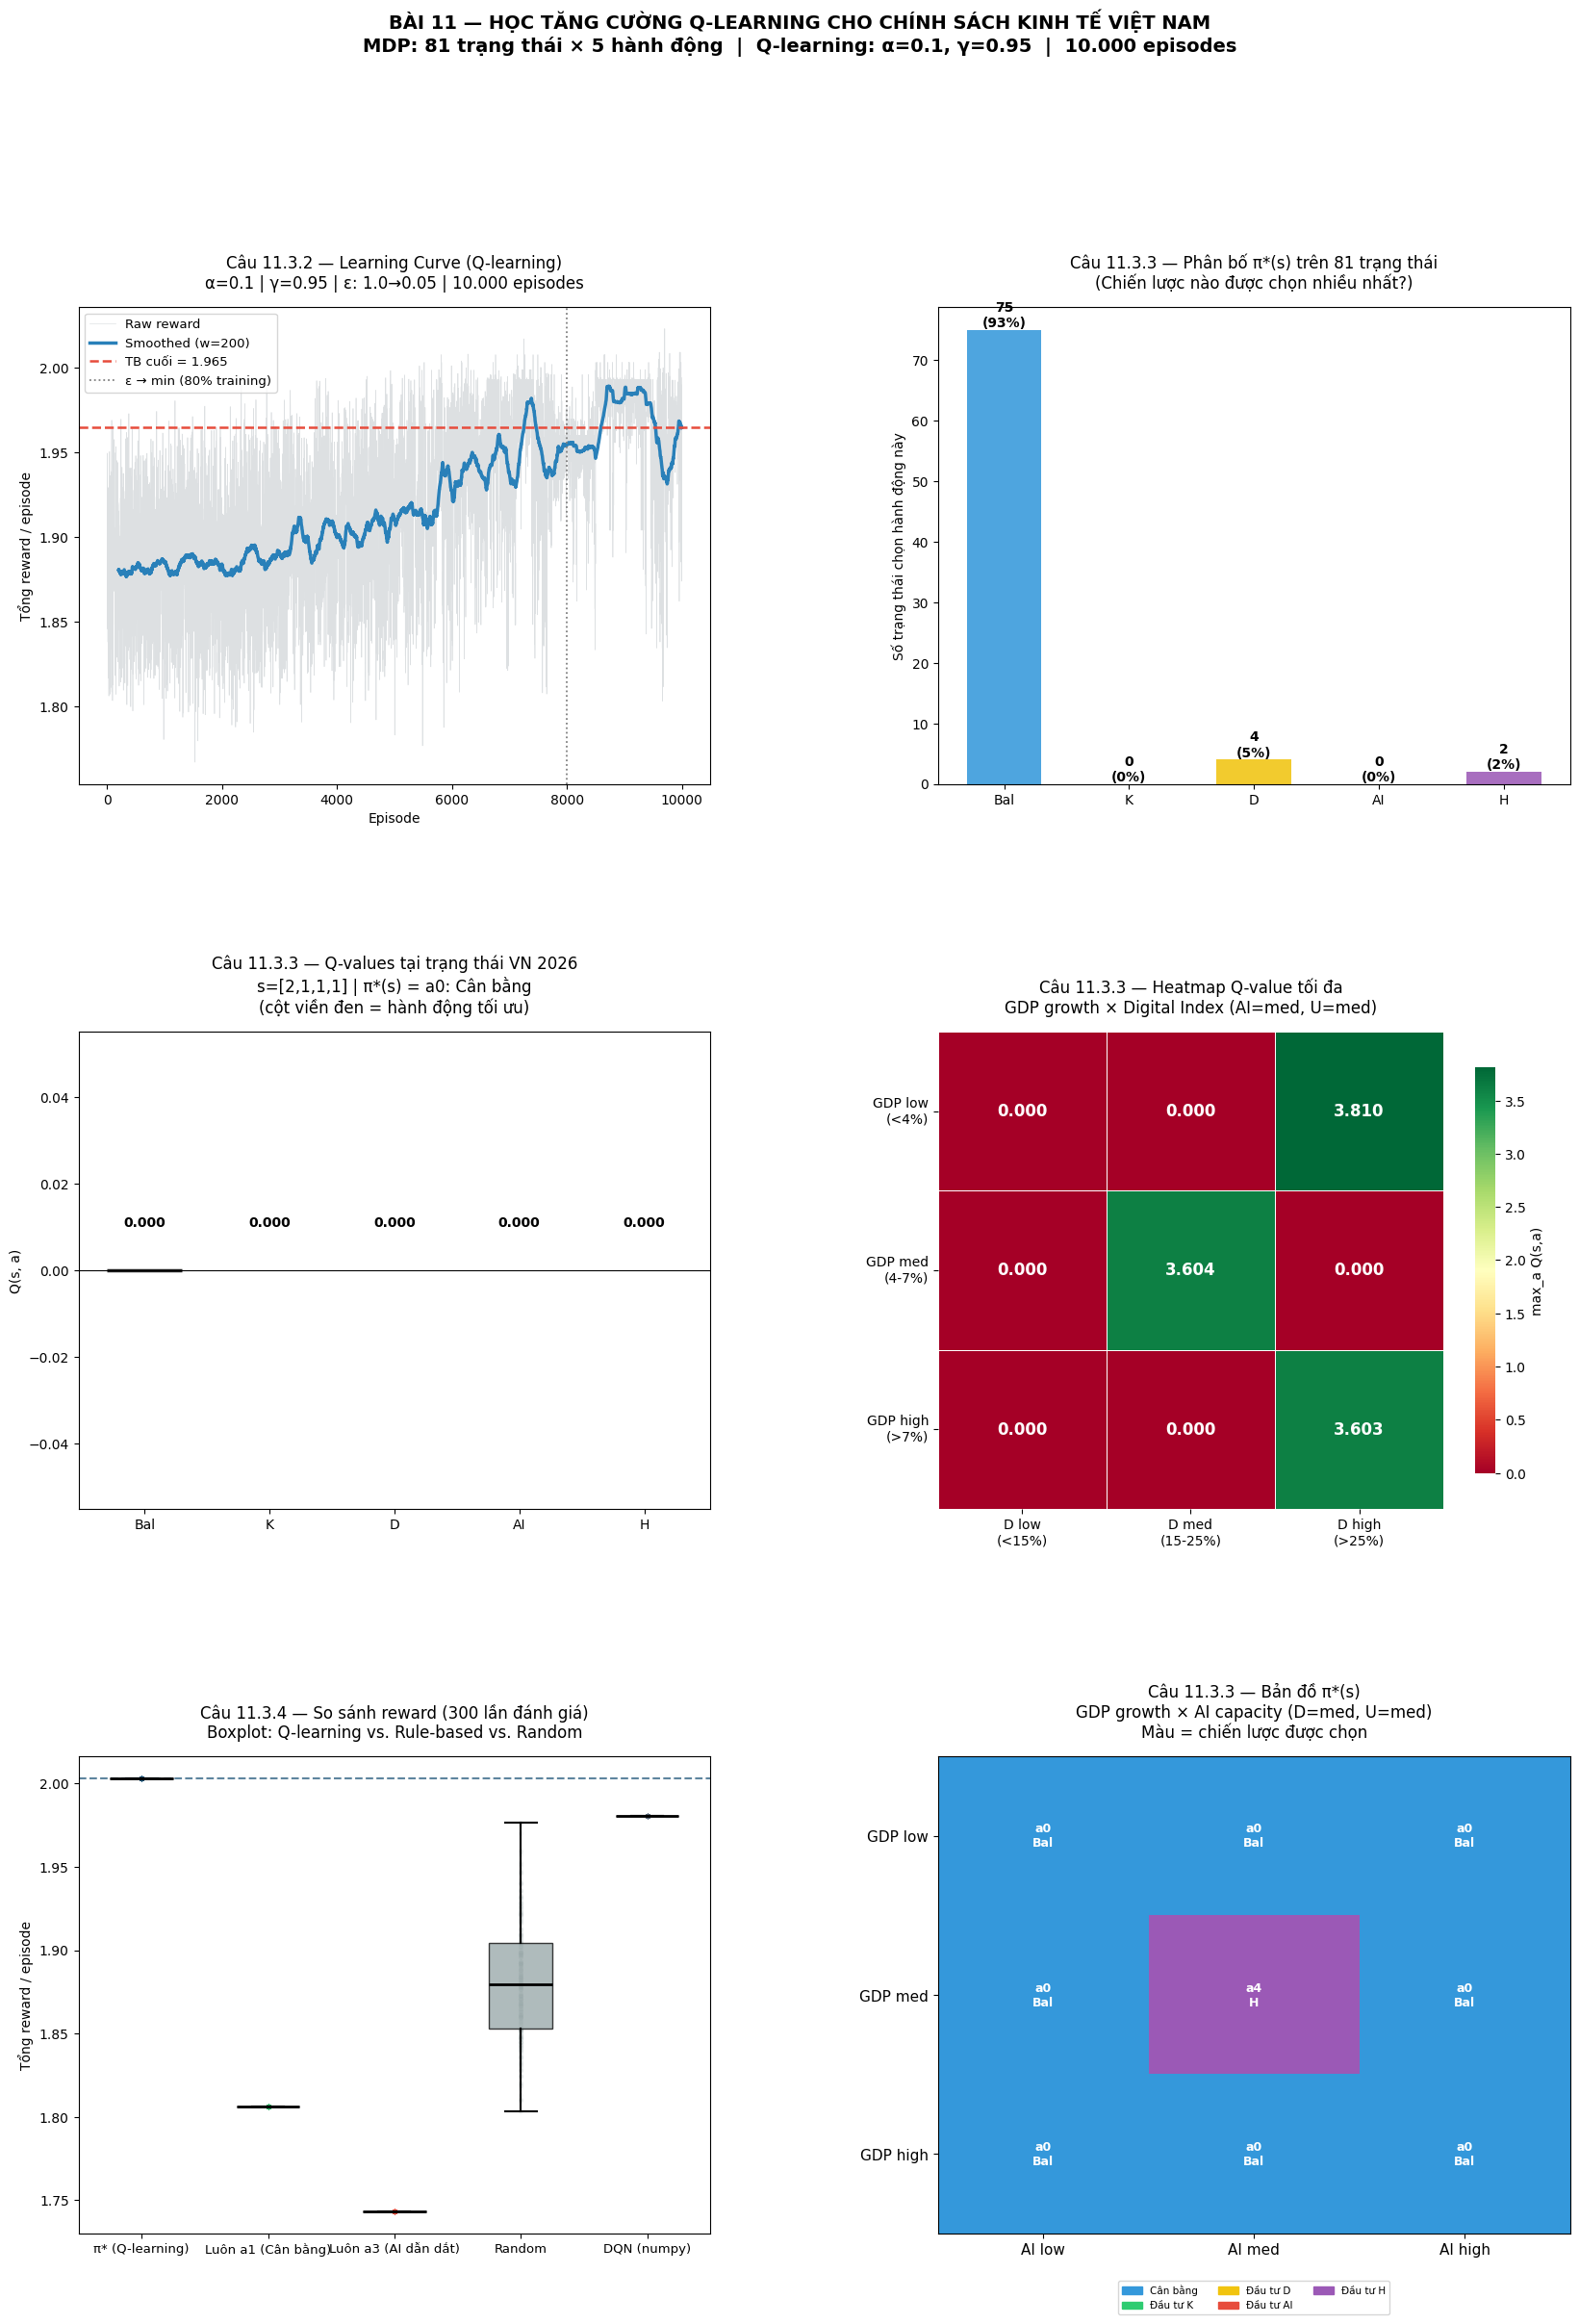

  [✓] bai11_rl_chinh.png — đã lưu


In [7]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import seaborn as sns
import matplotlib.patches as mpatches
import os # Import the os module

# Define colors for actions (placeholders - customize as needed)
C_ACT = ['#3498db', '#2ecc71', '#f1c40f', '#e74c3c', '#9b59b6'] # Blue, Green, Yellow, Red, Purple
ACT_SHORT = ['Bal', 'K', 'D', 'AI', 'H'] # Short labels for actions

print('\n  Đang vẽ biểu đồ chính...')

fig  = plt.figure(figsize=(20, 26))
fig.patch.set_facecolor('white')
gs   = GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.36)

# ── Panel 1: Learning curve ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
win = 200
smoothed  = np.convolve(rewards_hist, np.ones(win)/win, mode='valid')
ep_smooth = np.arange(win-1, len(rewards_hist))

ax1.plot(rewards_hist, color='#bdc3c7', lw=0.5, alpha=0.5, label='Raw reward')
ax1.plot(ep_smooth, smoothed, color='#2980b9', lw=2.5, label=f'Smoothed (w={win})')
ax1.axhline(np.mean(rewards_hist[-1000:]), color='#e74c3c', ls='--', lw=1.8,
            label=f'TB cuối = {np.mean(rewards_hist[-1000:]):.3f}')
ax1.axvline(len(rewards_hist)*0.8, color='gray', ls=':', lw=1.3,
            label='ε → min (80% training)')
ax1.set_title('Câu 11.3.2 — Learning Curve (Q-learning)\n'
              'α=0.1 | γ=0.95 | ε: 1.0→0.05 | 10.000 episodes', pad=14)
ax1.set_xlabel('Episode')
ax1.set_ylabel('Tổng reward / episode')
ax1.legend(fontsize=9.5)

# ── Panel 2: Phân bố hành động tối ưu ────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
act_counts = [(pi_full == a).sum() for a in range(5)]
bars2 = ax2.bar(range(5), act_counts, color=C_ACT, alpha=0.87, width=0.6)
for bar, cnt in zip(bars2, act_counts):
    ax2.text(bar.get_x()+bar.get_width()/2, cnt+0.5,
             f'{cnt}\n({cnt/81*100:.0f}%)',
             ha='center', fontsize=10, fontweight='bold')
ax2.set_xticks(range(5))
ax2.set_xticklabels(ACT_SHORT, fontsize=10)
ax2.set_ylabel('Số trạng thái chọn hành động này')
ax2.set_title('Câu 11.3.3 — Phân bố π*(s) trên 81 trạng thái\n'
              '(Chiến lược nào được chọn nhiều nhất?)', pad=14)

# ── Panel 3: Q-values tại trạng thái VN 2026 ─────────────────────
ax3 = fig.add_subplot(gs[1, 0])
s_vn = np.array([2, 1, 1, 1])
q_vn = Q_table[tuple(s_vn)]
bars3 = ax3.bar(range(5), q_vn, color=C_ACT, alpha=0.87, width=0.6)
# Highlight hành động tối ưu
best_a_vn = int(np.argmax(q_vn))
bars3[best_a_vn].set_edgecolor('black')
bars3[best_a_vn].set_linewidth(2.5)
for bar, v in zip(bars3, q_vn):
    ax3.text(bar.get_x()+bar.get_width()/2,
             v + (0.01 if v >= 0 else -0.05),
             f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax3.axhline(0, color='black', lw=0.8)
ax3.set_xticks(range(5))
ax3.set_xticklabels(ACT_SHORT, fontsize=10)
ax3.set_ylabel('Q(s, a)')
ax3.set_title(f'Câu 11.3.3 — Q-values tại trạng thái VN 2026\n'
              f's=[2,1,1,1] | π*(s) = a{best_a_vn}: {ACT_NAMES[best_a_vn]}\n'
              f'(cột viền đen = hành động tối ưu)', pad=14)

# ── Panel 4: Heatmap Q-values theo GDP growth × Digital Index ────
ax4 = fig.add_subplot(gs[1, 1])
# Lấy trung bình trên AI[med=1] và Unemp[med=1], và max theo action
q_gdp_dig = np.max(Q_table[:, :, 1, 1, :], axis=2)
df_hm = pd.DataFrame(q_gdp_dig,
                      index=['GDP low\n(<4%)', 'GDP med\n(4-7%)', 'GDP high\n(>7%)'],
                      columns=['D low\n(<15%)', 'D med\n(15-25%)', 'D high\n(>25%)'])
sns.heatmap(df_hm, ax=ax4,
            annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.7, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': 'max_a Q(s,a)', 'shrink': 0.85})
ax4.set_title('Câu 11.3.3 — Heatmap Q-value tối đa\n'
              'GDP growth × Digital Index (AI=med, U=med)', pad=14)
ax4.tick_params(axis='x', rotation=0,  labelsize=10)
ax4.tick_params(axis='y', rotation=0,  labelsize=10)

# ── Panel 5: So sánh reward 4 chính sách — boxplot ───────────────
ax5 = fig.add_subplot(gs[2, 0])
pol_names  = list(eval_results.keys())
pol_data   = [eval_results[k] for k in pol_names]
pol_colors = ['#1a5276', '#27ae60', '#e74c3c', '#95a5a6', '#5d6d7e'] # Added a new color for the 5th policy
bp = ax5.boxplot(pol_data, labels=pol_names, patch_artist=True,
                 medianprops=dict(color='black', lw=2.0),
                 whiskerprops=dict(lw=1.5),
                 capprops=dict(lw=1.5))
for patch, col in zip(bp['boxes'], pol_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
for i, (name, data) in enumerate(eval_results.items()):
    ax5.scatter([i+1]*len(data), data, alpha=0.06, color=pol_colors[i], s=8)
ax5.axhline(np.median(eval_results['π* (Q-learning)']),
            color='#1a5276', ls='--', lw=1.5, alpha=0.7)
ax5.set_title('Câu 11.3.4 — So sánh reward (300 lần đánh giá)\n'
              'Boxplot: Q-learning vs. Rule-based vs. Random', pad=14)
ax5.set_ylabel('Tổng reward / episode')
ax5.tick_params(axis='x', labelsize=9.5)

# ── Panel 6: Heatmap hành động π*(s) [GDP × AI | D=med, U=med] ──
ax6 = fig.add_subplot(gs[2, 1])
pi_gdp_ai = pi_full[:, 1, :, 1]   # D=med(1), U=med(1)
df_pi = pd.DataFrame(pi_gdp_ai,
                      index=['GDP low','GDP med','GDP high'],
                      columns=['AI low','AI med','AI high'])
# Tạo cmap rời rạc 5 màu
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap5 = ListedColormap(C_ACT)
norm5 = BoundaryNorm([-0.5,0.5,1.5,2.5,3.5,4.5], ncolors=5)
im6 = ax6.imshow(pi_gdp_ai, cmap=cmap5, norm=norm5, aspect='auto')
ax6.set_xticks([0,1,2])
ax6.set_xticklabels(['AI low','AI med','AI high'], fontsize=11)
ax6.set_yticks([0,1,2])
ax6.set_yticklabels(['GDP low','GDP med','GDP high'], fontsize=11)
for i in range(3):
    for j in range(3):
        a_ij = pi_gdp_ai[i, j]
        ax6.text(j, i, f'a{a_ij}\n{ACT_SHORT[a_ij]}',
                 ha='center', va='center', fontsize=9,
                 color='white', fontweight='bold')
ax6.set_title('Câu 11.3.3 — Bản đồ π*(s)\n'
              'GDP growth × AI capacity (D=med, U=med)\n'
              'Màu = chiến lược được chọn', pad=14)
patches6 = [mpatches.Patch(color=C_ACT[a], label=ACT_NAMES[a]) for a in range(5)]
ax6.legend(handles=patches6, fontsize=7.5, loc='lower center',
           bbox_to_anchor=(0.5,-0.18), ncol=3)

fig.suptitle(
    'BÀI 11 — HỌC TĂNG CƯỜNG Q-LEARNING CHO CHÍNH SÁCH KINH TẾ VIỆT NAM\n'
    'MDP: 81 trạng thái × 5 hành động  |  Q-learning: α=0.1, γ=0.95  |  10.000 episodes',
    fontsize=14, fontweight='bold', y=0.999,
)

# Create the directory if it doesn't exist
output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'bai11_rl_chinh.png'),
            bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print('  [✓] bai11_rl_chinh.png — đã lưu')
